<a href="https://colab.research.google.com/github/stella1298/AIFFEL_Quest_EPA/blob/master/LLM/LLM01/260916_Bert_Haena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 프로젝트 : mini BERT 만들기

vocab size를 8000으로 줄이고, 전체 파라미터 사이즈가 1M 정도가 되는 아주 작은 mini BERT 모델을 만들어 10 Epoch까지 학습시킨 모델을 만들어 보는 것입니다.

In [1]:
#구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = '/content/drive/MyDrive/Aiffel_EPA/bert_pretrain'
DATA_DIR  = f'{BASE_DIR}/data'
MODEL_DIR = f'{BASE_DIR}/models'

!mkdir -p "{DATA_DIR}" "{MODEL_DIR}"
!wget -nc https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip -P "{DATA_DIR}"
!unzip -n "{DATA_DIR}/kowiki.txt.zip" -d "{DATA_DIR}"
!ls -l "{DATA_DIR}"

Mounted at /content/drive
File ‘/content/drive/MyDrive/Aiffel_EPA/bert_pretrain/data/kowiki.txt.zip’ already there; not retrieving.

Archive:  /content/drive/MyDrive/Aiffel_EPA/bert_pretrain/data/kowiki.txt.zip
total 2240940
-rw------- 1 root root 1385052685 Sep 16 12:10 bert_pre_train.json
-rw------- 1 root root  666544979 Jul 11  2020 kowiki.txt
-rw------- 1 root root  243123354 Jun 23  2021 kowiki.txt.zip


In [2]:
#sentencepiece, tqdm 설치
!pip install -q sentencepiece tqdm

#사용할 라이브러리 확인
import torch
import numpy
import pandas
import matplotlib
import json
import re

#print(torch.__version__)
#print(numpy.__version__)
#print(pandas.__version__)
#print(matplotlib.__version__)
#print(json.__version__)
#print(re.__version__)
#표 출력을 위한 설정
%matplotlib inline

#폰트 설정
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'

#한글 폰트 출력을 위한 설정(나눔바른고딕)
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(fontpath) # 폰트를 matplotlib 에 등록
plt.rc('font', family=fm.FontProperties(fname=fontpath).get_name())
plt.rc('axes', unicode_minus=False)

#print("표 나와라 뿅!")
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

# 여러 셀이 공유하는 장치 설정 (GPU 런타임이면 cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

2.11.0+cu128
device: cuda


In [5]:
###Tokenizer 준비
corpus_file = f'{DATA_DIR}/kowiki.txt'
#prefix = f'{MODEL_DIR}/ko_32000'
prefix = f"{MODEL_DIR}/ko_8000"

#vocab_size = 32000
vocab_size = 8000

if not os.path.exists(f'{prefix}.model'):   # 드라이브에 이미 있으면 다시 만들지 않는다
    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7}"
        " --model_type=bpe --max_sentence_length=999999"
        " --input_sentence_size=1000000 --shuffle_input_sentence=true"
        " --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK]"
        " --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS]"
        " --user_defined_symbols=[SEP],[CLS],[MASK]")
print(os.listdir(MODEL_DIR))

data_dir, model_dir = DATA_DIR, MODEL_DIR

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(f"{model_dir}/ko_8000.model")

print("Vocabulary size:", len(vocab))
print("PAD:", vocab.pad_id())
print("UNK:", vocab.unk_id())
print("BOS:", vocab.bos_id())
print("EOS:", vocab.eos_id())
print("SEP:", vocab.piece_to_id("[SEP]"))
print("CLS:", vocab.piece_to_id("[CLS]"))
print("MASK:", vocab.piece_to_id("[MASK]"))

['ko_8000.model', 'ko_8000.vocab']
Vocabulary size: 8007
PAD: 0
UNK: 1
BOS: 2
EOS: 3
SEP: 4
CLS: 5
MASK: 6


In [11]:
### MASK 생성
#create_pretrain_mask() : Masked LM을 위한 코퍼스 생성 메소드
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label


def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

#데이터셋 완성
corpus_file = f'{DATA_DIR}/kowiki.txt'

# line count 확인
total = 0
with open(corpus_file, 'r') as in_f:
    for line in in_f:
        total += 1

total

3957761

In [17]:
# 위 코드들을 함수로 정리한 것입니다. 각 단계가 어느 셀에서 왔는지 확인하며 읽어 보세요.
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

In [18]:
# make_pretrain_data() : BERT pretrain 데이터셋 생성 메소드
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

In [19]:
pretrain_json_path = f'{DATA_DIR}/bert_pre_train.json'

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

  0%|          | 0/3957761 [00:00<?, ?it/s]

In [20]:
# MLM masking 결과 확인
sample = json.loads(open(pretrain_json_path, encoding="utf-8").readline())

print("Tokens :", sample["tokens"])
print("Mask idx:", sample["mask_idx"])
print("Labels :", sample["mask_label"])
print("Mask count:", len(sample["mask_idx"]))

Tokens : ['[CLS]', '일', '▁~', '▁)', '는', '▁민주', '당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '7', '7', '년', '▁~', '▁1981', '년', ')', '이다', '.', '▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카운', '티', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁마을', '에서', '▁태어났다', '.', '[MASK]', '[MASK]', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁195', '3', '년', '▁미국', '[MASK]', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '[MASK]', '[MASK]', '▁벌', '었다', '.', '▁그의', '▁별', '명이', '▁"', '땅', '콩', '[MASK]', '[MASK]', '[MASK]', '▁(', 'P', 'e', 'an', 'ut', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려', '졌다', '.', '[SEP]', '[MASK]', '[MASK]', '▁카', '터', '[SEP]']
Mask idx: [35, 36, 37, 38, 43, 44, 49, 50, 51, 77, 78, 94, 95, 105, 106, 107, 123, 124]
Labels : ['▁플', '레', '인', '스', '▁조지', '아', '▁졸업', '하였다', '.', '▁미국', '▁해군', '▁돈', '을', '

In [21]:
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total

918242

In [22]:
n_seq = 128
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_seq - 3

# 만약 일반적인 Numpy Array에다 데이터를 로딩한다면 이렇게 되겠지만
# enc_tokens = np.zeros((total, n_seq), np.int32)
# dec_tokens = np.zeros((total, n_seq), np.int32)
# labels_nsp = np.zeros((total,), np.int32)
# labels_mlm = np.zeros((total, n_seq), np.int32)

# np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
# memmap 파일은 드라이브가 아닌 Colab 로컬 디스크에 둔다 (세션마다 다시 만들지만 그것이 memmap 의 의도)
MEMMAP_DIR = '/content/memmap'
os.makedirs(MEMMAP_DIR, exist_ok=True)
enc_tokens = np.memmap(filename=f'{MEMMAP_DIR}/enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
segments = np.memmap(filename=f'{MEMMAP_DIR}/segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
labels_nsp = np.memmap(filename=f'{MEMMAP_DIR}/labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
labels_mlm = np.memmap(filename=f'{MEMMAP_DIR}/labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))


enc_tokens[0], enc_tokens[-1], segments[0], segments[-1], labels_nsp[0], labels_nsp[-1], labels_mlm[0], labels_mlm[-1]

(memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0

In [23]:
# 라인 단위로 처리
with open(pretrain_json_path, "r") as f:
    for i, line in enumerate(tqdm(f, total=total)):
        if 5 < i:  # 테스트를 위해서 5개만 확인
            break
        data = json.loads(line)
        # encoder token
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        enc_token += [0] * (n_seq - len(enc_token))
        # segment
        segment = data["segment"]
        segment += [0] * (n_seq - len(segment))
        # nsp label
        label_nsp = data["is_next"]
        # mlm label
        mask_idx = np.array(data["mask_idx"], dtype=int)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=int)
        label_mlm = np.full(n_seq, dtype=int, fill_value=0)
        label_mlm[mask_idx] = mask_label

        print(data)
        print("enc_token:", enc_token)
        print("segment:", segment)
        print("label_nsp:", label_nsp)
        print("label_mlm:", label_mlm)
        print()

        assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

        enc_tokens[i] = enc_token
        segments[i] = segment
        labels_nsp[i] = label_nsp
        labels_mlm[i] = label_mlm

  0%|          | 0/918242 [00:00<?, ?it/s]

{'tokens': ['[CLS]', '일', '▁~', '▁)', '는', '▁민주', '당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '7', '7', '년', '▁~', '▁1981', '년', ')', '이다', '.', '▁지', '미', '▁카', '터', '는', '▁조지', '아', '주', '▁섬', '터', '▁카운', '티', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁마을', '에서', '▁태어났다', '.', '[MASK]', '[MASK]', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁195', '3', '년', '▁미국', '[MASK]', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '[MASK]', '[MASK]', '▁벌', '었다', '.', '▁그의', '▁별', '명이', '▁"', '땅', '콩', '[MASK]', '[MASK]', '[MASK]', '▁(', 'P', 'e', 'an', 'ut', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려', '졌다', '.', '[SEP]', '[MASK]', '[MASK]', '▁카', '터', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [24]:
#load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수
def load_pre_train_data(vocab, filename, n_seq, count=None, memmap_dir='/content/memmap'):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :param memmap_dir: memmap 파일을 둘 폴더 (Colab 로컬 디스크)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    os.makedirs(memmap_dir, exist_ok=True)
    enc_tokens = np.memmap(filename=f'{memmap_dir}/enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename=f'{memmap_dir}/segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=f'{memmap_dir}/labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=f'{memmap_dir}/labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [25]:
## 128000건만 메모리에 로딩
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000


In [26]:
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([   5, 3622,  202,  242, 3595, 1102, 3717,  783,  246,   49, 3625,
          793,  664, 1661, 3675, 3675, 3618,  202, 2936, 3618, 3610,   16,
         3592,   18, 3679,  208, 3707, 3595, 1751, 3623, 3639,  622, 3707,
         3489, 3831,    6,    6,    6,    6, 1400,   10, 1598, 3592,    6,
            6,   42, 3637,  833, 3617, 1139,   52, 3592,   13,   81,   87,
         1521, 2249,   25, 3772, 3865, 3660, 3624, 3805, 3865, 4186, 3629,
         3772, 3594,  247, 3718, 1226,   34,   52, 3592,  477, 3645, 3618,
          246,    6,   14, 1506,  171, 3870,  418,  166, 1675, 4284, 3865,
         3696, 3676,  592,   22, 5016,  395,    6,    6,  815,   17, 3592,
          306,  584,  925,  103, 4303, 4284,    6,    6,    6,  100, 3871,
         3649,  256, 2493,  314,  336, 3728,  181, 3610, 3596,  488,  375,
         3592,    4,    6,    6,  208, 3707,    4], dtype=int32),
 memmap([   5,   22, 3620, 4378,    4,   22, 3620, 4378, 3611, 3868, 1422,
         3883,  707, 3610, 3606, 1

In [27]:
#BERT 모델 구현
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

print("get_pad_mask, get_ahead_mask define!")

get_pad_mask, get_ahead_mask define!


In [28]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("gelu define!")

gelu define!


In [29]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("Config define!")

Config define!


In [30]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs
print("SharedEmbedding define!")

SharedEmbedding define!


In [31]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

print("PositionEmbedding Define!")

PositionEmbedding Define!


In [32]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

print("ScaleDotProductAttention Define!")

ScaleDotProductAttention Define!


In [33]:
# 앞 절의 Transformer 와 같은 Multi-Head Attention 입니다. attn_mask 가 head 축으로 브로드캐스트되는 부분을 확인하세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
print("MultiHeadAttention Define!")

MultiHeadAttention Define!


In [34]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("PositionWiseFeedForward Define!")

PositionWiseFeedForward Define!


In [35]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("EncoderLayer Define!")

EncoderLayer Define!


In [36]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("BERT Define!")

BERT Define!


In [37]:
# Pooled Output(NSP 분류 헤드) 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: logits (softmax 미적용; CrossEntropyLoss가 내부 처리)
        """
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs  # raw logits 반환 (softmax 제거: CrossEntropyLoss가 처리)

print("PooledOutput Define!")

PooledOutput Define!


In [38]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        outputs_nsp = logits_cls  # raw logits (이중 softmax 제거)

        outputs_mlm = logits_lm  # raw logits (softmax 제거)
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("PreTrainModel Define!")

PreTrainModel Define!


In [39]:
config = Config({
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,
    "d_ff": 384,
    "dropout": 0.1,
    "layernorm_epsilon": 0.001,
    "n_layer": 2,
    "n_seq": 128,
    # tokenizer에서 직접 가져오기
    "n_vocab": len(vocab),
    "i_pad": vocab.pad_id(),
})

In [93]:
# 동작 확인용 아주 작은 설정. 실제 모델은 아래 '모델 생성' 셀에서 어휘 크기를 토크나이저에 맞춰 다시 정한다.
#config = Config({
#    "d_model": 128, "n_head": 4, "d_head": 64, "dropout": 0.1, "d_ff": 1024,
#    "layernorm_epsilon": 0.001, "n_layer": 3, "n_seq": 256,
#    "n_vocab": 5000, "i_pad": 0,
#})

In [40]:
n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [41]:
# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()
        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), labels_mlm_batch.view(-1))
        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        total_loss_batch.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")

Epoch 1/10 - Loss: 9.586993217468262
Epoch 2/10 - Loss: 9.56901502609253
Epoch 3/10 - Loss: 9.538555145263672
Epoch 4/10 - Loss: 9.557030200958252
Epoch 5/10 - Loss: 9.49589729309082
Epoch 6/10 - Loss: 9.494916439056396
Epoch 7/10 - Loss: 9.451487064361572
Epoch 8/10 - Loss: 9.423115253448486
Epoch 9/10 - Loss: 9.406558513641357
Epoch 10/10 - Loss: 9.397595882415771


In [42]:
#pretrain 진행
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 계산하고 optimizer 에 적용
        """
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for g in self.optimizer.param_groups:
                g['lr'] = lr
        return lr

print("CosineSchedule Define!")

CosineSchedule Define!


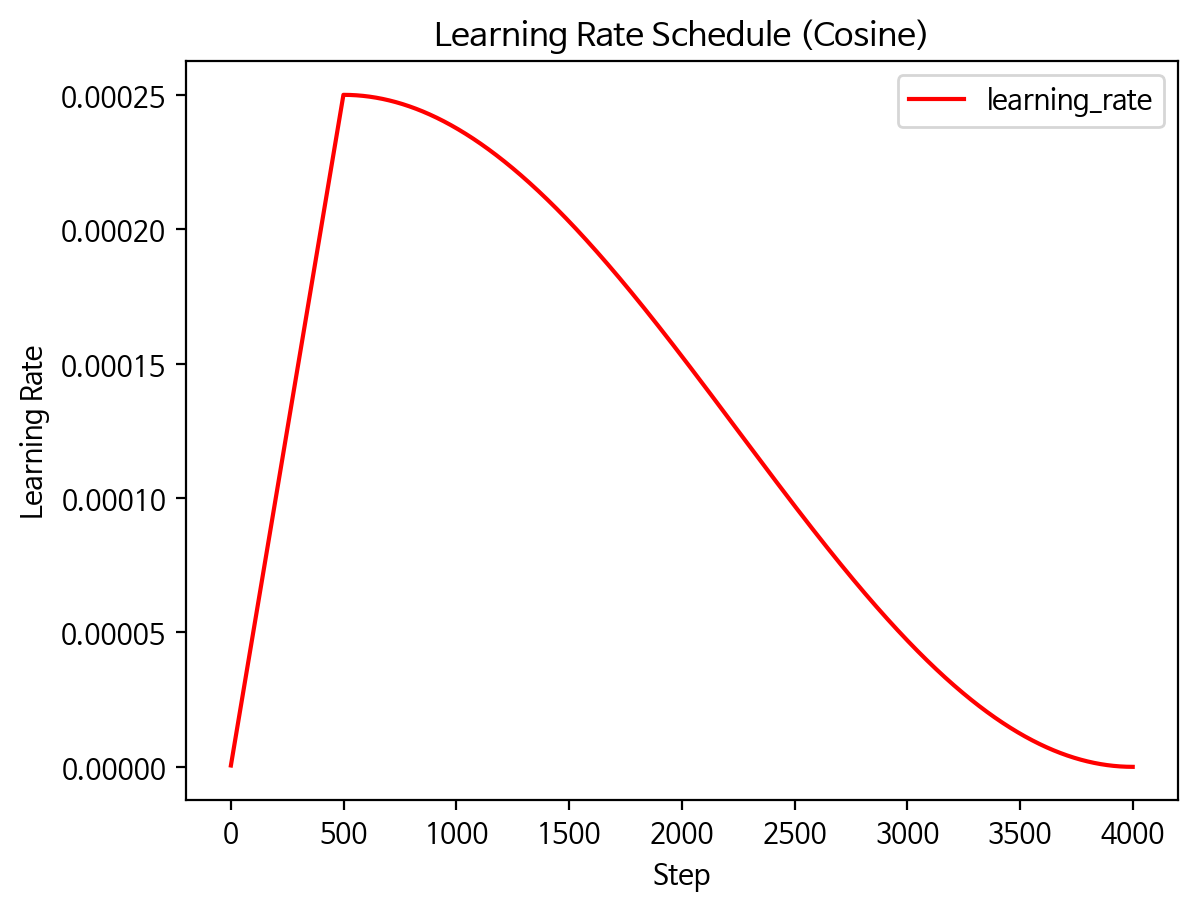

In [43]:
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

In [44]:
# 모델 생성을 위한 라이브러리 설치
!pip install torchinfo

In [45]:
# 모델 생성
from torchinfo import summary

config.n_seq = 128
config.n_vocab = len(vocab)      # 8007 = 8000 + 특수 토큰 7
config.i_pad = vocab.pad_id()    # 0
#pre_train_model = build_model_pre_train(config)
pre_train_model = build_model_pre_train(config).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)], dtypes=[torch.long, torch.long])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 96]                  --
│    └─SharedEmbedding: 2-1                                  [10, 128, 96]             768,672
│    └─PositionEmbedding: 2-2                                [10, 128, 96]             --
│    │    └─Embedding: 3-1                                   [10, 128, 96]             12,288
│    └─Embedding: 2-3                                        [10, 128, 96]             192
│    └─LayerNorm: 2-4                                        [10, 128, 96]             192
│    └─Dropout: 2-5                                          [10, 128, 96]             --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 96]          

In [46]:
#모델 크기 확인
total_params = sum(
    p.numel() for p in pre_train_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in pre_train_model.parameters()
    if p.requires_grad
)

print(f"전체 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")
print(f"모델 크기: 약 {total_params / 1e6:.2f}M")

전체 파라미터: 1,014,528
학습 가능 파라미터: 1,014,528
모델 크기: 약 1.01M


In [47]:
epochs = 10
batch_size = 64

# optimizer + learning rate schedule
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)
optimizer = optim.Adam(pre_train_model.parameters(), lr=0.0)   # lr 은 스케줄러가 매 step 정한다
learning_rate_scheduler = CosineSchedule(optimizer, train_steps=train_steps, warmup_steps=max(100, train_steps // 10), max_lr=2.5e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)  # 0=[PAD]/비마스크 위치 제외

train_steps: 20000


In [48]:
pre_train_inputs = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
pre_train_labels = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

train_dataset = TensorDataset(pre_train_inputs[0], pre_train_inputs[1], pre_train_labels[0], pre_train_labels[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

pre_train_model.to(device)

history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()
        learning_rate_scheduler.step()  # warmup → cosine 스케줄로 lr 갱신

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_mask = (labels_mlm_batch != 0)  # 마스킹된 위치만 평가
        mlm_acc = ((logits_mlm.argmax(dim=-1) == labels_mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 결과 저장
    history['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader)}, MLM Loss: {total_mlm_loss / len(train_dataloader)}, "
          f"NSP Accuracy: {total_nsp_acc / len(train_dataloader)}, MLM Accuracy: {total_mlm_acc / len(train_dataloader)}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"{MODEL_DIR}/bert_pre_train_epoch_{epoch+1}.pt")

Epoch 1/10 - Loss: 8.390975442886353, NSP Loss: 0.6237129479199648, MLM Loss: 7.767262492656708, NSP Accuracy: 0.594421875, MLM Accuracy: 0.024224553908366944
Epoch 2/10 - Loss: 7.9989562728405, NSP Loss: 0.5924618781507015, MLM Loss: 7.406494396686554, NSP Accuracy: 0.5949765625, MLM Accuracy: 0.028779666939750315
Epoch 3/10 - Loss: 7.952391217947007, NSP Loss: 0.5892860118150711, MLM Loss: 7.363105204820633, NSP Accuracy: 0.5947734375, MLM Accuracy: 0.030177323017735035
Epoch 4/10 - Loss: 7.887351429224014, NSP Loss: 0.5867441286146641, MLM Loss: 7.300607307910919, NSP Accuracy: 0.595421875, MLM Accuracy: 0.03398635532986373
Epoch 5/10 - Loss: 7.777537838220597, NSP Loss: 0.5838115630596876, MLM Loss: 7.193726280927658, NSP Accuracy: 0.6011328125, MLM Accuracy: 0.04256619278155267
Epoch 6/10 - Loss: 7.656910894155502, NSP Loss: 0.5811760783046483, MLM Loss: 7.075734813451767, NSP Accuracy: 0.607609375, MLM Accuracy: 0.05228512734081596
Epoch 7/10 - Loss: 7.574331757545472, NSP Loss: 

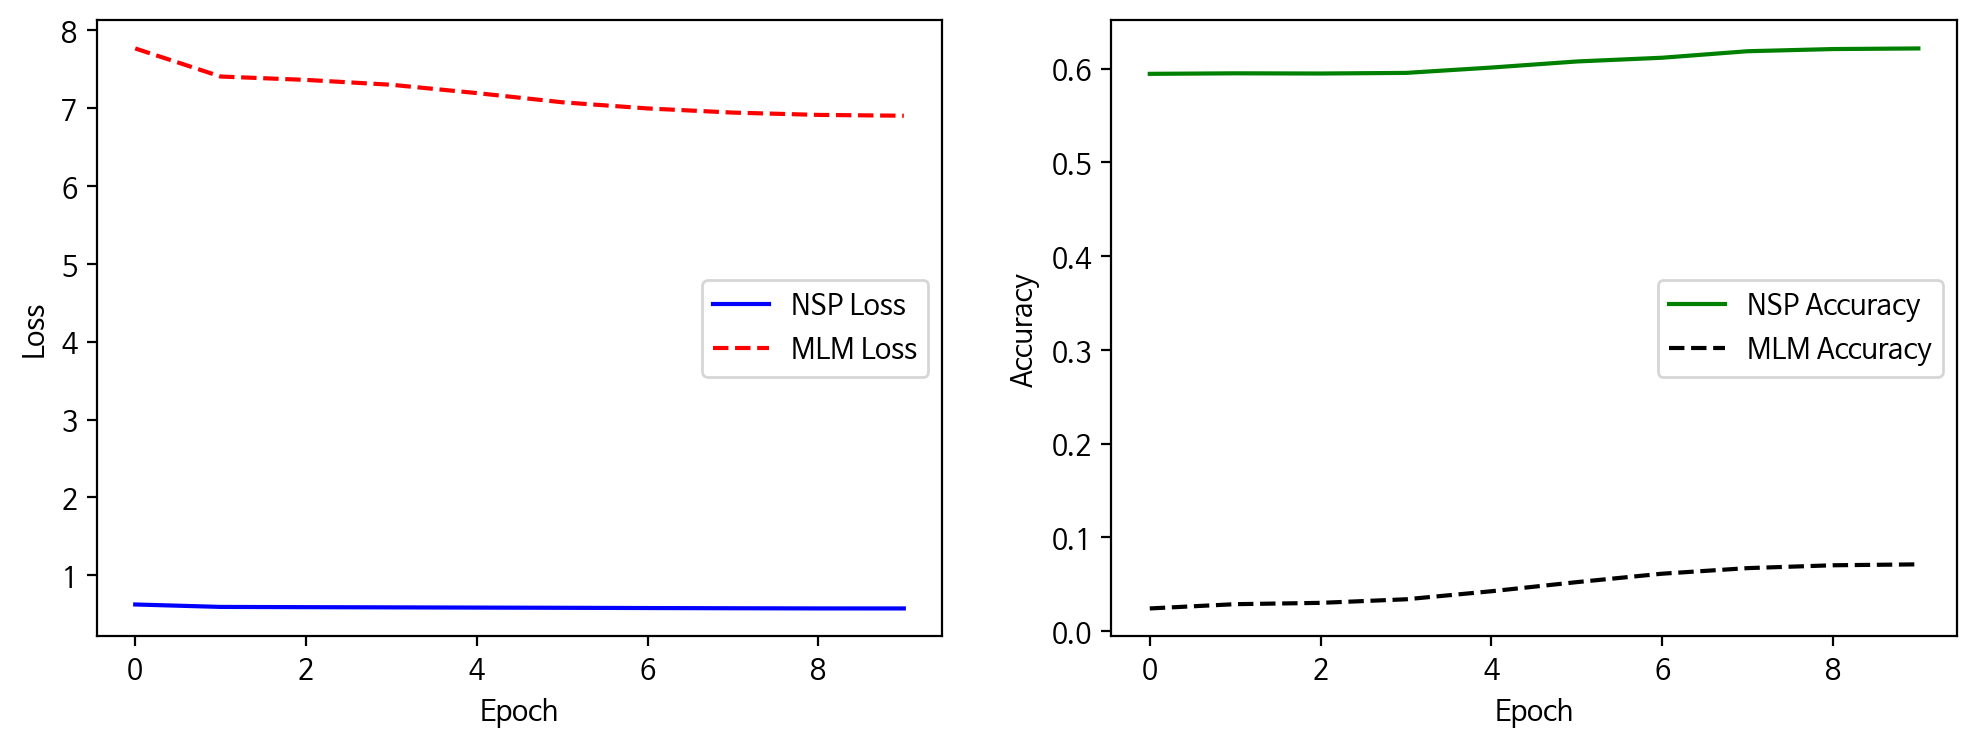

In [49]:
#import matplotlib.pyplot as plt

# training result
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()